# パッケージのインストール

In [1]:
# パッケージのインストール
list.of.packages <- c("rTensor", "nnTensor",
    "RColorBrewer", "TeachingDemos")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)){
    install.packages(new.packages,
        repos="https://cloud.r-project.org/", type="source")
}

# パッケージの読み込み

In [2]:
library("rTensor")
library("nnTensor")
library("RColorBrewer")
library("TeachingDemos")

Warning message:
“no DISPLAY variable so Tk is not available”


# 定数の設定

In [3]:
N_DISPLAY <- 10        # 表示する被験者数
N_RANK <- 20           # 行列分解のランク（基底数）
IMG_DIM <- c(92, 112)  # 顔画像の画素数 (幅 x 高さ)

# 関数定義

In [4]:
# 顔画像を2x5グリッドで表示する関数
plot_faces <- function(tensor, slice, colvec){
    layout(rbind(1:5, 6:10))
    for(i in seq(N_DISPLAY)){
        image(tensor@data[,,i,slice], col=colvec, main=i)
    }
}

# 行列分解の係数（基底画像）を表示する関数
plot_coef <- function(coef_matrix, colvec, n=N_RANK){
    nrow <- ceiling(n / 5)
    layout(matrix(seq(nrow * 5), nrow=nrow, byrow=TRUE))
    for(i in seq(n)){
        tmp <- as.matrix(coef_matrix[,i])
        dim(tmp) <- IMG_DIM
        image(tmp, col=rev(colvec), main=i)
    }
}

# スコア（各被験者の重み）を2次元散布図で表示する関数
plot_score <- function(score_matrix, facedata, colvec){
    plot(score_matrix[,1:2], pch=16, cex=2,
        axes=FALSE, xlab="", ylab="")
    abline(v=0)
    abline(h=0)
    n <- dim(facedata@data)[3]
    for(i in seq(n)){
        subplot(image(facedata@data[,,i,1], col=colvec,
            main=i, axes=FALSE),
            x=score_matrix[i,1], y=score_matrix[i,2],
            size=c(0.45, 0.45))
    }
}

# カラーパレットの設定

In [5]:
colvec <- rev(brewer.pal(9, "Greys"))

# ORL顔画像データのダウンロード

AT&T Laboratoriesが収集した顔画像データセット。40人の被験者 × 10種類の撮影条件（角度・表情・照明）で構成される。各画像は92×112ピクセルのグレースケールで、4階テンソル (92×112×40×10) として格納されている。

In [6]:
# ORL顔画像データのダウンロード
# AT&T Laboratoriesが収集した顔画像データセット
# 40人の被験者 × 10種類の撮影条件（角度・表情・照明）
# 各画像は92×112ピクセルのグレースケール → 4階テンソル (92×112×40×10)
options(timeout = 600)
facedata <- load_orl()
str(facedata)

Formal class 'Tensor' [package ".GlobalEnv"] with 3 slots
  ..@ num_modes: int 4
  ..@ modes    : int [1:4] 92 112 40 10
  ..@ data     : num [1:92, 1:112, 1:40, 1:10] 0.2 0.2 0.2 0.176 0.204 ...


# 顔画像の表示（角度1、最初の10人）

同一の撮影条件でも、被験者ごとに顔の形状・特徴が異なることを確認する。

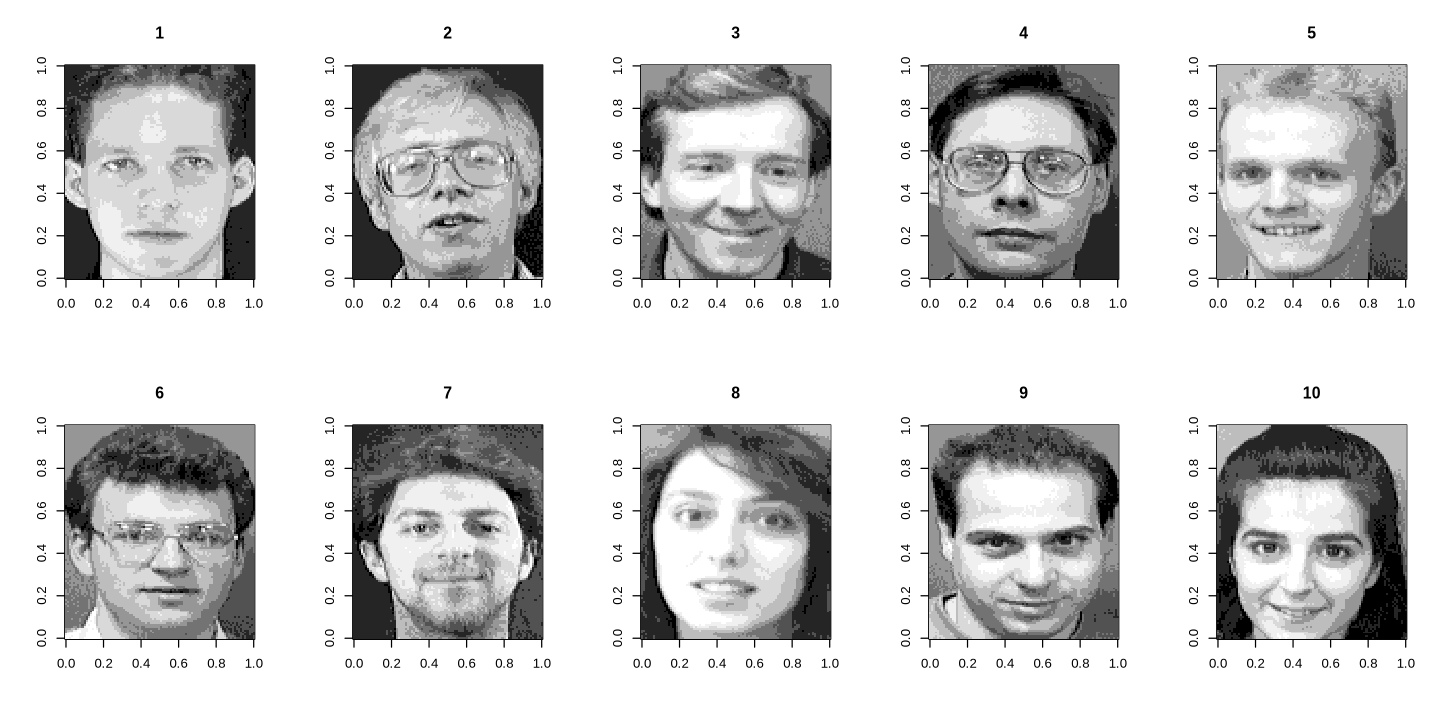

In [7]:
# 顔画像の表示（角度1、最初の10人）
# 同一の撮影条件でも、被験者ごとに顔の形状・特徴が異なることを確認
options(repr.plot.width=12, repr.plot.height=6)
plot_faces(facedata, slice=1, colvec)

# 顔画像の表示（角度2、最初の10人）

撮影条件が変わると、同じ被験者でも見え方が変化する。

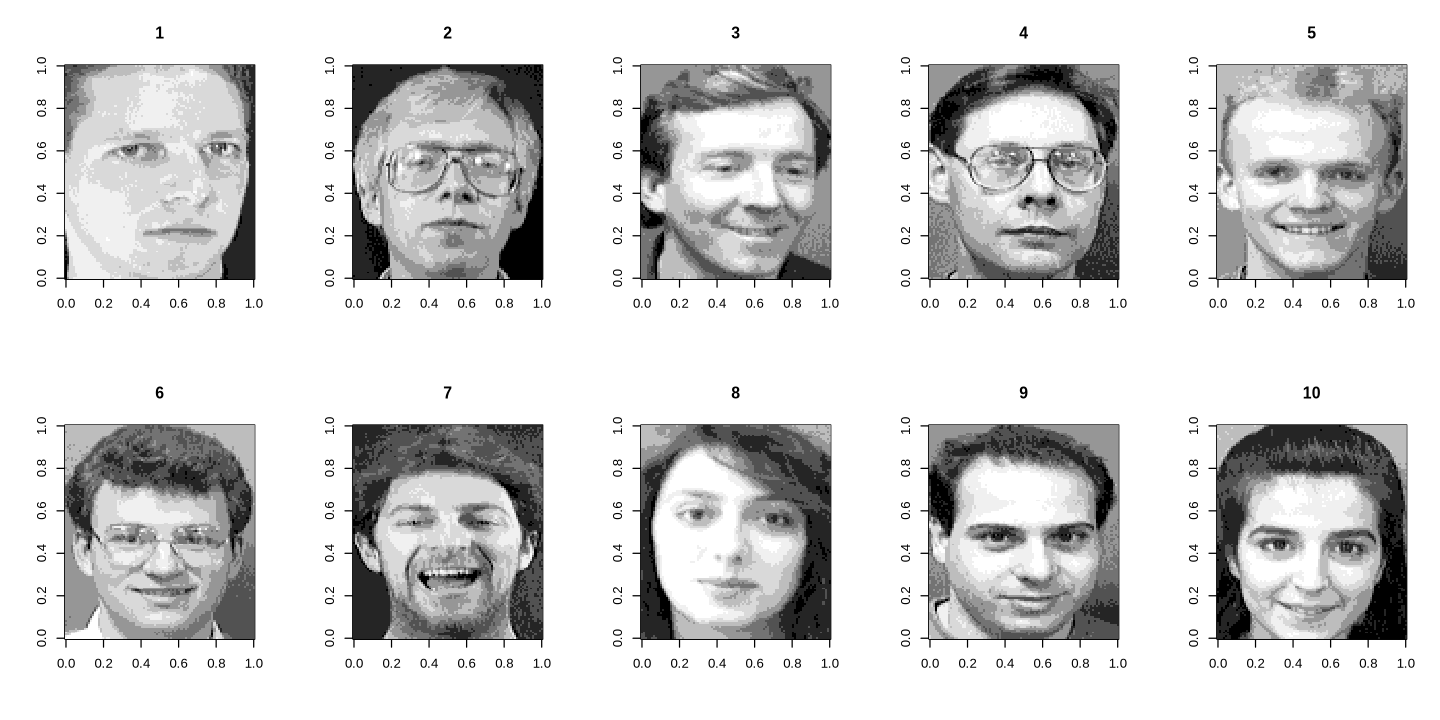

In [8]:
# 顔画像の表示（角度2、最初の10人）
# 撮影条件が変わると、同じ被験者でも見え方が変化する
options(repr.plot.width=12, repr.plot.height=6)
plot_faces(facedata, slice=2, colvec)

# テンソルの3モード展開により行列化

全40人の角度1のみを使用し、92×112=10,304次元の画素ベクトルが40本並んだ行列 (10,304×40) を作成する。この高次元データを行列分解により低次元に要約する。

In [9]:
# テンソルの3モード展開により行列化（全40人、角度1のみ使用）
# 92×112=10304次元の画素ベクトルが40本並んだ行列 (10304×40) を作成
# この高次元データを行列分解により低次元に要約する
matdata <- cs_unfold(facedata[,,,1], m=3)@data

# 平均顔の計算と表示

40人の画素値を平均した「平均顔」。PCAではこの平均顔を引いた残差（個人差）を分析する。

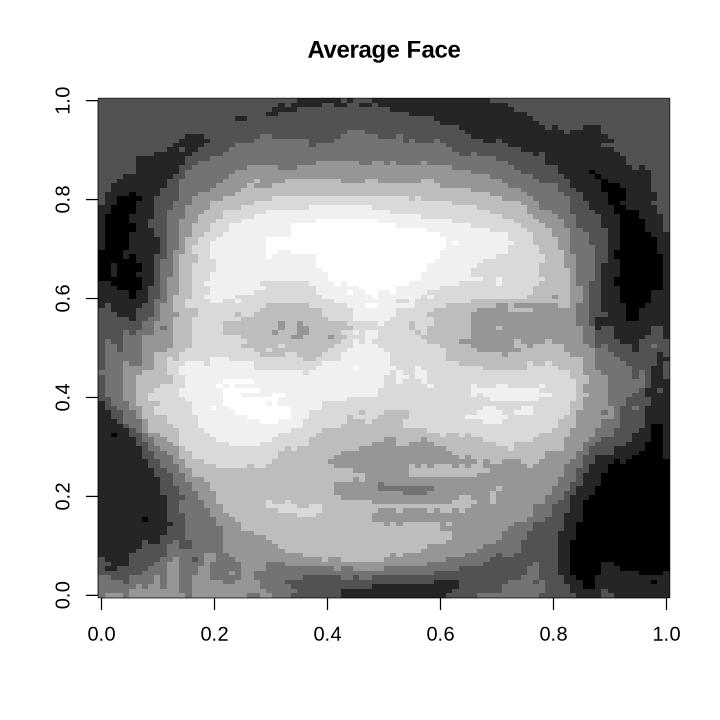

In [10]:
# 平均顔の計算と表示
# 40人の画素値を平均した「平均顔」
# PCAではこの平均顔を引いた残差（個人差）を分析する
options(repr.plot.width=6, repr.plot.height=6)
average_face <- rowMeans(matdata)
dim(average_face) <- IMG_DIM
image(average_face, col=colvec, main="Average Face")

# PCA（主成分分析）

データを中心化（平均を引く）した上で、分散が最大となる方向を順に求める。各主成分は顔全体にわたるグローバルなパターン（固有顔, Eigenface）になる。上位5成分で分散の約54%、上位20成分で約86%を説明する。

In [11]:
# PCA（主成分分析）: 全40人のデータで計算
# 上位5成分で分散の約54%、上位20成分で約86%を説明する
res_pca <- prcomp(t(matdata), center=TRUE, scale=FALSE)

## PCAの係数（固有顔, Eigenface）の表示

各固有顔は正負の値を取り、顔全体に広がるグローバルなパターンになる。

**表示の色: 黒=値が大きい、白=値が小さい（元画像と白黒反転）。**

- **PC1** (19.5%): 顔全体の明暗（照明条件の違い）を捉える
- **PC2以降**: 顔の左右差、上下差、表情の違いなどを捉える

正の領域と負の領域が打ち消し合う形で、被験者間の差異の方向を表現するため、各固有顔は特定の顔パーツではなく、**顔全体の変動パターン**を示す。

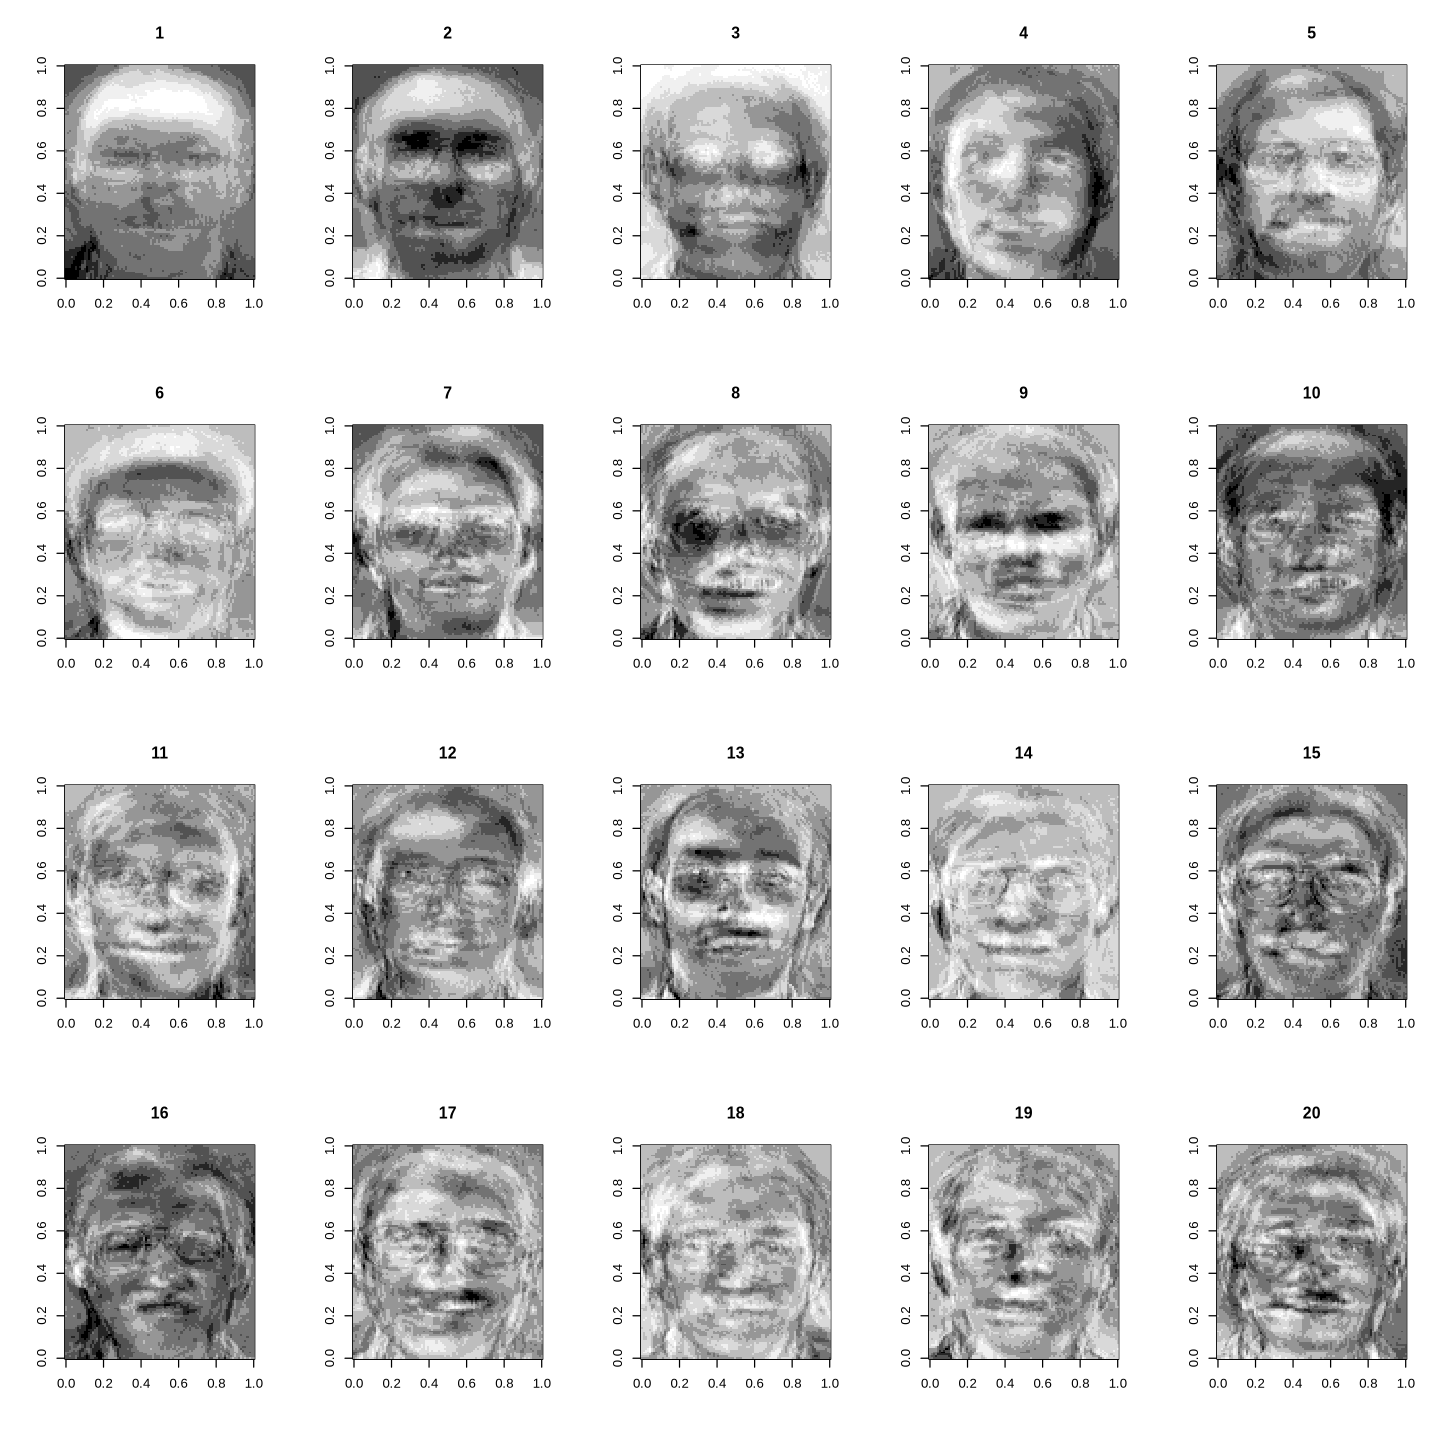

In [12]:
## PCAの係数（固有顔, Eigenface）の表示（上位N_RANK個）
## 表示は黒=値が大きい、白=値が小さい（元画像と白黒反転）
##
## 各固有顔は正負の値を取り、顔全体に広がるグローバルなパターンになる
## PC1 (19.5%): 顔全体の明暗（照明条件の違い）を捉える
## PC2以降: 顔の左右差、上下差、表情の違いなどを捉える
## 正の領域と負の領域が打ち消し合う形で、被験者間の差異の方向を表現するため、
## 各固有顔は特定の顔パーツではなく、顔全体の変動パターンを示す
options(repr.plot.width=12, repr.plot.height=12)
plot_coef(res_pca$rotation, colvec)

## PCAのスコアの表示（全40人）

スコアは「各被験者の顔が、平均顔からどの固有顔の方向にどれだけずれているか」を示す。

- PC1のスコアが**正**の被験者 → PC1の固有顔で黒い（値が大きい）領域が平均より明るい
- PC1のスコアが**負**の被験者 → 逆にその領域が平均より暗い

したがって、スコアプロット上で近い被験者は、同じ固有顔に同程度の重みを持つ → 顔全体の「見た目の印象」が似ていることを意味する。

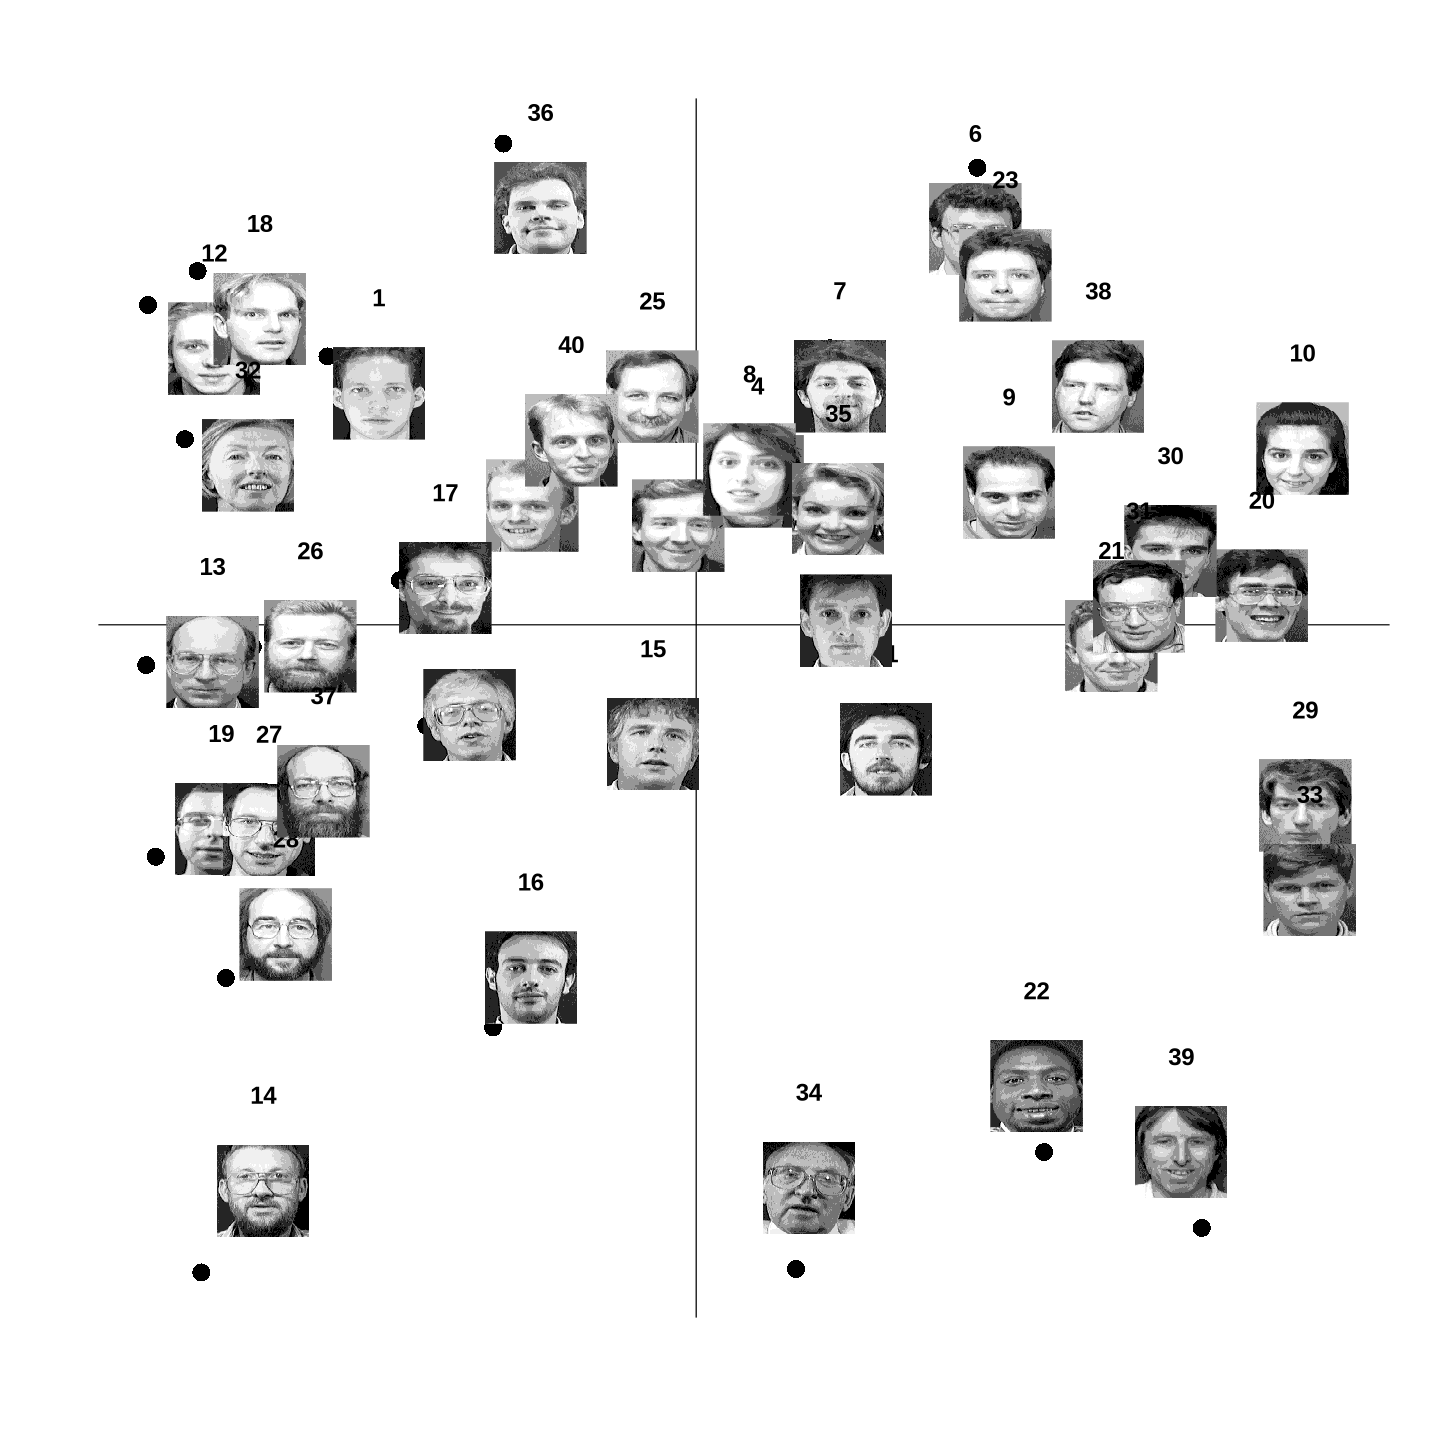

In [13]:
## PCAのスコアの表示（全40人）
## スコアは「各被験者の顔が、平均顔からどの固有顔の方向にどれだけずれているか」を示す
## 例: PC1のスコアが正の被験者は、PC1の固有顔で黒い（値が大きい）領域が平均より明るい
##     PC1のスコアが負の被験者は、逆にその領域が平均より暗い
## したがって、スコアプロット上で近い被験者は、同じ固有顔に同程度の重みを持つ
## → 顔全体の「見た目の印象」が似ていることを意味する
options(repr.plot.width=12, repr.plot.height=12)
plot_score(res_pca$x, facedata, colvec)

# NMF（非負値行列因子分解）

元の行列を2つの非負行列の積 X ≈ U V^T に分解する。非負制約により、基底画像は「足し合わせて顔を構成するパーツ」になる。PCAと異なり、引き算（正負の打ち消し）を使えないため、局所的な特徴を捉えやすい。

NMFは初期値がランダムなため、再現性のためにseedを固定する。

In [14]:
# NMF（非負値行列因子分解）: 全40人のデータでランクN_RANKに分解
# NMFは初期値がランダムなため、再現性のためにseedを固定する
set.seed(12345)
res_nmf <- NMF(matdata, J=N_RANK)

## NMFの係数（基底画像, パーツ）の表示

**表示の色: 黒=値が大きい（そのパーツが強い）、白=値が小さい。**

PCAの固有顔と比べて以下の違いが見られる:

- 各基底画像は顔の**特定の領域**に集中し、それ以外は白い（値が小さい）。PCAでは顔全体に正負が広がっていたのに対し、NMFは非負のため「顔のどの部分を使っているか」が直感的に読み取れる。
- 基底ごとに顔の**異なる領域を担当**している。例えば、額周辺を捉える基底、目・鼻の中央部を捉える基底、顎・輪郭を捉える基底、左右どちらかに偏った基底などが見られる。
- 複数の基底が同じ顔領域を異なるパターンで捉えていることもある → 同じ「目の周り」でも、目の開き具合や眉の形ごとに別の基底になる。

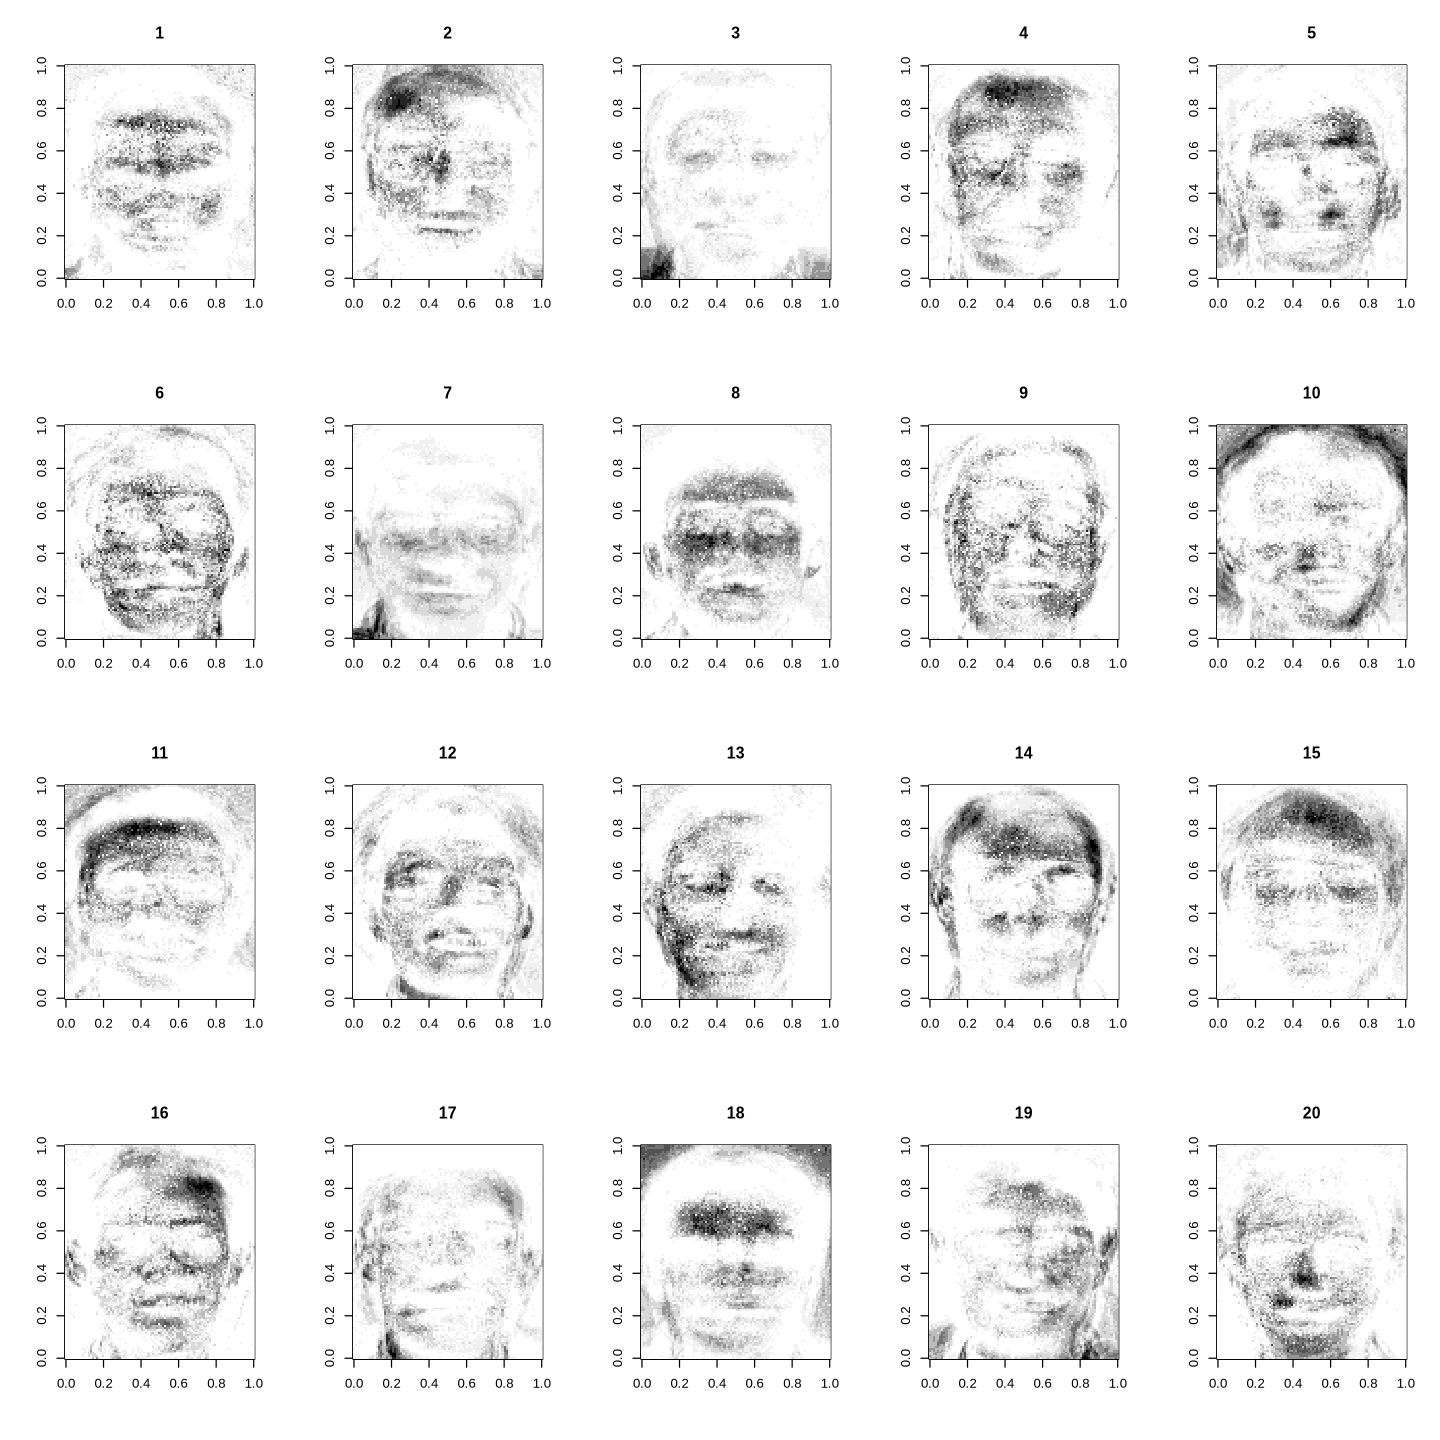

In [15]:
## NMFの係数（基底画像, パーツ）の表示（N_RANK個）
## 表示は黒=値が大きい（そのパーツが強い）、白=値が小さい
##
## PCAの固有顔と比べて以下の違いが見られる:
##   - 各基底画像は顔の特定の領域に集中し、それ以外は白い（値が小さい）
##     PCAでは顔全体に正負が広がっていたのに対し、NMFは非負のため
##     「顔のどの部分を使っているか」が直感的に読み取れる
##   - 基底ごとに顔の異なる領域を担当している
##     例: 額周辺を捉える基底、目・鼻の中央部を捉える基底、
##         顎・輪郭を捉える基底、左右どちらかに偏った基底など
##   - 複数の基底が同じ顔領域を異なるパターンで捉えていることもある
##     → 同じ「目の周り」でも、目の開き具合や眉の形ごとに別の基底になる
options(repr.plot.width=12, repr.plot.height=12)
plot_coef(res_nmf$U, colvec)

## NMFのスコアの表示（全40人）

スコアは「各被験者の顔が、どのパーツをどの程度持っているか」の重みを示す。

### PCAのスコアとの違い

- NMFのスコアは常に**非負** → 各パーツの「存在量」として解釈できる（PCAでは正負があり「平均からのずれの方向」としての解釈だった）
- ある被験者のスコアが高い基底は、その被験者の顔にそのパーツが**強く存在**する
- スコアがゼロに近い基底は、その被験者の顔にはそのパーツが**不要**ということ
- 顔 ≈ パーツ1×重み1 + パーツ2×重み2 + ... という**足し算だけで再構成**される

### ローディングとスコアの対応の見方

上の基底画像で黒い領域が似ている基底に、同じ被験者が高いスコアを持つ場合、その被験者の顔はその領域の特徴が強いことを示す。例えば:

- 被験者9はBasis 1（中央部）と5（右下）に高いスコアを持つ
- 被験者6はBasis 7（左下）と18（中央左）に高いスコアを持つ

基底画像と照合すると、各被験者の顔のどの部分が特徴的かが読み取れる。

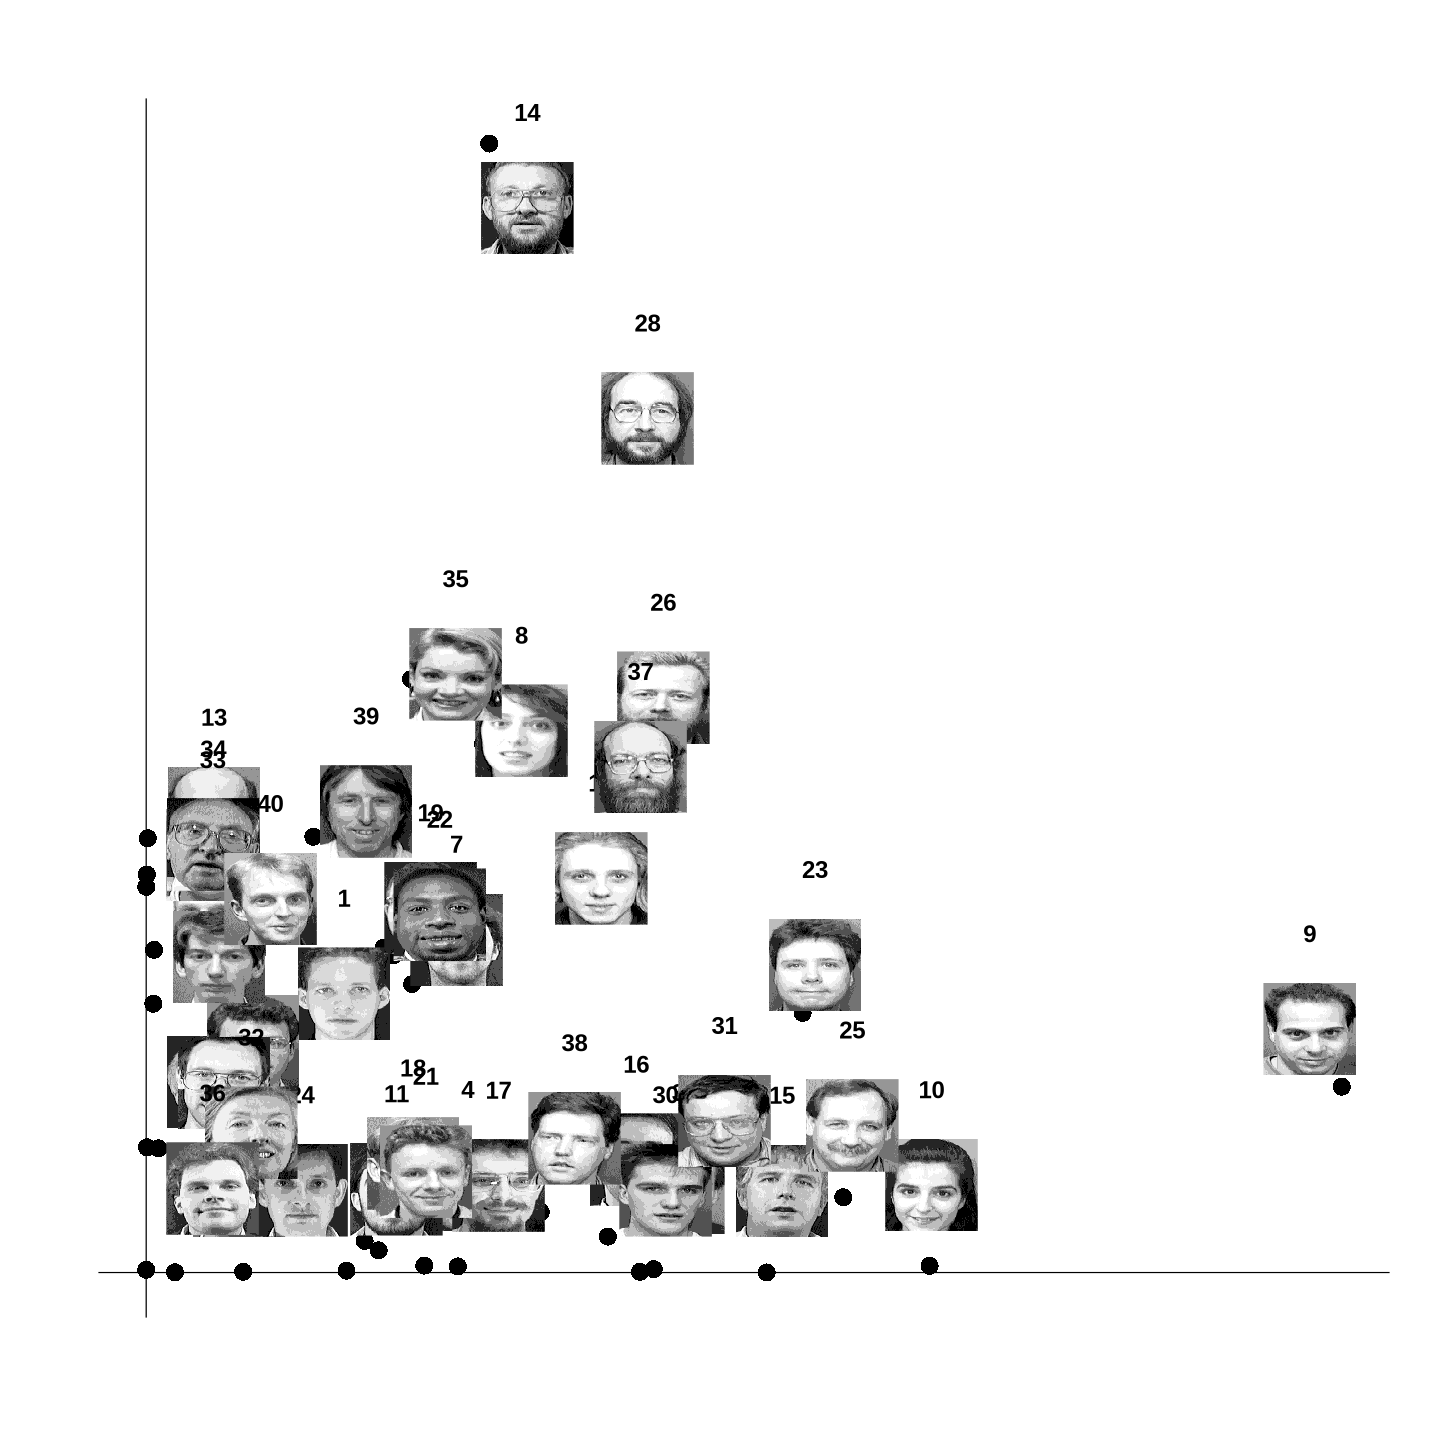

In [16]:
## NMFのスコアの表示（全40人）
## スコアは「各被験者の顔が、どのパーツをどの程度持っているか」の重みを示す
##
## PCAのスコアとの違い:
##   - NMFのスコアは常に非負 → 各パーツの「存在量」として解釈できる
##     （PCAでは正負があり「平均からのずれの方向」としての解釈だった）
##   - ある被験者のスコアが高い基底は、その被験者の顔にそのパーツが強く存在する
##   - スコアがゼロに近い基底は、その被験者の顔にはそのパーツが不要ということ
##   → 顔 ≈ パーツ1×重み1 + パーツ2×重み2 + ... という足し算で再構成される
##
## ローディングとスコアの対応の見方:
##   上の基底画像で黒い領域が似ている基底に、同じ被験者が高いスコアを持つ場合、
##   その被験者の顔はその領域の特徴が強いことを示す
##   例: 被験者9はBasis 1（中央部）と5（右下）に高いスコアを持ち、
##       被験者6はBasis 7（左下）と18（中央左）に高いスコアを持つ
##       → 基底画像と照合すると、各被験者の顔のどの部分が特徴的か読み取れる
options(repr.plot.width=12, repr.plot.height=12)
plot_score(res_nmf$V, facedata, colvec)

# セッション情報

In [17]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 9.5 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /home/koki/miniconda3/envs/r-notebook/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Tokyo
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] TeachingDemos_2.13 RColorBrewer_1.1-3 nnTensor_1.3.0     rTensor_1.4.9     

loaded via a namespace (and not attached):
 [1] gtable_0.3.6      jsonlite_2.0.0    compiler_4.5.3    crayon_1.5.3     
 [5] maps_3.4.3        R